<a href="https://colab.research.google.com/github/firstsignal/activation-geometry-sentiment/blob/main/ch6_plurality_phase_slot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install transformer-lens
import numpy as np, torch, gc
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from transformer_lens import HookedTransformer

# ---- sentiment axis sets (ch4/ch5 recipe) ----
pos_matched = [
    "The meal at the restaurant was absolutely wonderful.",
    "Her performance in the final act was brilliant.",
    "The weather on the coast stayed lovely all week.",
    "His speech at the ceremony sounded inspiring.",
    "The ending of the novel felt satisfying.",
]
neg_matched = [
    "The meal at the restaurant was absolutely terrible.",
    "Her performance in the final act was dreadful.",
    "The weather on the coast stayed miserable all week.",
    "His speech at the ceremony sounded tedious.",
    "The ending of the novel felt hollow.",
]
sent_pairs = [
    ("The concert in the park sounded wonderful and the crowd stayed late.",
     "The concert in the park sounded terrible and the crowd stayed late."),
    ("Her garden looked beautiful after the rain stopped falling.",
     "Her garden looked dreadful after the rain stopped falling."),
    ("The service at the hotel was excellent and the staff seemed calm.",
     "The service at the hotel was awful and the staff seemed calm."),
    ("His first attempt at the recipe tasted delicious and the kitchen smelled good.",
     "His first attempt at the recipe tasted disgusting and the kitchen smelled good."),
    ("The view from the window seemed lovely in the morning light.",
     "The view from the window seemed miserable in the morning light."),
    ("The lecture on physics felt inspiring and the students asked questions.",
     "The lecture on physics felt tedious and the students asked questions."),
    ("The journey through the mountains was pleasant and the roads stayed clear.",
     "The journey through the mountains was horrible and the roads stayed clear."),
    ("The film about the ocean looked stunning and the music matched well.",
     "The film about the ocean looked boring and the music matched well."),
    ("The bread from the bakery smelled amazing and the queue moved quickly.",
     "The bread from the bakery smelled horrid and the queue moved quickly."),
    ("The report on the findings read brilliant and the figures looked clear.",
     "The report on the findings read hopeless and the figures looked clear."),
]

# ---- tense axis sets + test pairs (ch5, verbatim) ----
past_ax = [
    "She walked to the station and caught the early train.",
    "They finished the project and celebrated last night.",
    "He wrote the letter and posted it yesterday morning.",
    "We visited the museum and admired the old paintings.",
    "I cooked dinner and washed the dishes afterwards.",
]
pres_ax = [
    "She walks to the station and catches the early train.",
    "They finish the project and celebrate tonight.",
    "He writes the letter and posts it this morning.",
    "We visit the museum and admire the old paintings.",
    "I cook dinner and wash the dishes afterwards.",
]
tense_pairs = [
    ("The gardener watered the plants and the flowers looked bright.",
     "The gardener waters the plants and the flowers looked bright."),
    ("The children played in the yard and the dog barked loudly.",
     "The children play in the yard and the dog barked loudly."),
    ("The chef cooked the meal and the guests waited patiently.",
     "The chef cooks the meal and the guests waited patiently."),
    ("The student answered the question and the teacher nodded slowly.",
     "The student answers the question and the teacher nodded slowly."),
    ("The painter finished the mural and the crowd gathered outside.",
     "The painter finishes the mural and the crowd gathered outside."),
    ("The driver parked the van and the workers unloaded boxes.",
     "The driver parks the van and the workers unloaded boxes."),
    ("The singer performed the song and the audience clapped warmly.",
     "The singer performs the song and the audience clapped warmly."),
    ("The farmer planted the seeds and the field stretched wide.",
     "The farmer plants the seeds and the field stretched wide."),
    ("The writer typed the chapter and the editor read quietly.",
     "The writer types the chapter and the editor read quietly."),
]

# ---- plurality axis sets (ch2, verbatim) ----
sing_ax = [
    "The dog runs across the field near the river.",
    "A child plays in the garden every afternoon.",
    "The teacher explains the lesson to the class.",
    "The bird sings loudly from the tall tree.",
    "The car waits outside the old station.",
]
plur_ax = [
    "The dogs run across the fields near the rivers.",
    "Children play in the gardens every afternoon.",
    "The teachers explain the lessons to the classes.",
    "The birds sing loudly from the tall trees.",
    "The cars wait outside the old stations.",
]
# plurality TEST pairs — past tense (no agreement), noun-only single-token flip
plural_pairs = [
    ("The dog slept on the warm floor and the house stayed quiet.",
     "The dogs slept on the warm floor and the house stayed quiet."),
    ("The girl walked to the station and the streets looked empty.",
     "The girls walked to the station and the streets looked empty."),
    ("The book fell from the shelf and the noise startled everyone.",
     "The books fell from the shelf and the noise startled everyone."),
    ("The car stopped at the light and the engine kept running.",
     "The cars stopped at the light and the engine kept running."),
    ("The bird landed on the wire and the garden fell silent.",
     "The birds landed on the wire and the garden fell silent."),
    ("The window opened without warning and the papers blew everywhere.",
     "The windows opened without warning and the papers blew everywhere."),
    ("The letter arrived on Monday and the reply came quickly.",
     "The letters arrived on Monday and the reply came quickly."),
    ("The player scored in the final and the crowd cheered loudly.",
     "The players scored in the final and the crowd cheered loudly."),
    ("The key opened the front door and the hallway smelled fresh.",
     "The keys opened the front door and the hallway smelled fresh."),
]

def flip_and_window(tp, tn):
    if tp.shape != tn.shape: return None, None
    d = (tp[0] != tn[0]).nonzero().flatten()
    if len(d) != 1: return None, None
    f = d.item()
    return f, (f + 1, tp.shape[1])

print("cell 1 loaded:", len(sent_pairs), "sentiment,",
      len(tense_pairs), "tense,", len(plural_pairs), "plurality pairs")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.6 MB/s eta 0:00:00
cell 1 loaded: 10 sentiment, 9 tense, 9 plurality pairs


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/911M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Loaded pretrained model pythia-410m into HookedTransformer
building axes…

running probes…
  skipped (tokenization): The bread from the bakery smelled amazing and
SENTIMENT: pairs used 9/10 | within-pair alignment 0.802 | cycles 2.72
  skipped (tokenization): The gardener watered the plants and the flowe
TENSE    : pairs used 8/9 | within-pair alignment 0.937 | cycles 2.73
PLURALITY: pairs used 9/9 | within-pair alignment 0.637 | cycles 3.98

--- phase geometry (the verdict block) ---
plurality vs sentiment: Δφ = +0.99 rad (0.31·π) | R = 0.36 | r = +0.372
plurality vs tense    : Δφ = -0.43 rad (0.14·π) | R = 0.18 | r = -0.022
tense vs sentiment    : Δφ = +1.29 rad (0.41·π) | R = 0.29 | r = -0.030

P3 reads: |Δφ(plu,tense)| 0.43 vs |Δφ(plu,sent)| 0.99 — closer to TENSE (trust only if both R > ~0.5)


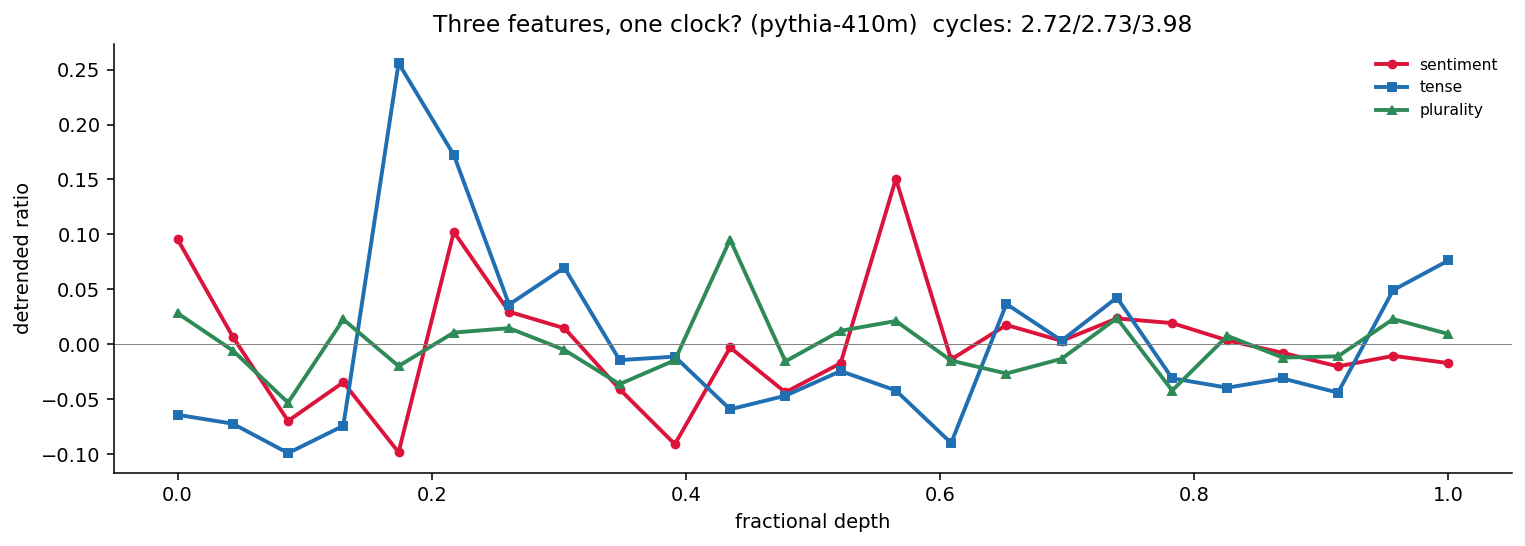

In [ ]:
name = "pythia-410m"
model = HookedTransformer.from_pretrained_no_processing(name, dtype=torch.float16)
nL = model.cfg.n_layers
x = np.linspace(0, 1, nL)

def all_layer_means(prompts):
    outs = []
    for p in prompts:
        _, c = model.run_with_cache(model.to_tokens(p))
        outs.append(torch.stack([c["resid_post", L][0].mean(dim=0).float()
                                 for L in range(nL)]))
    return torch.stack(outs)

def build_axes(setA, setB):
    A, B = all_layer_means(setA), all_layer_means(setB)
    return {L: (lambda a: a / a.norm())(A[:, L].mean(0) - B[:, L].mean(0))
            for L in range(nL)}

def feature_wave(axes, pairs, label):
    per_pair, used = [], 0
    for s_a, s_b in pairs:
        tpk, tnk = model.to_tokens(s_a), model.to_tokens(s_b)
        f, win = flip_and_window(tpk, tnk)
        if f is None:
            print(f"  skipped (tokenization): {s_a[:45]}"); continue
        used += 1
        _, cp = model.run_with_cache(tpk); _, cn = model.run_with_cache(tnk)
        curve = []
        for L in range(nL):
            dvec = (cp["resid_post", L][0] - cn["resid_post", L][0]).float()
            ax = axes[L]
            on  = (dvec @ ax).abs()[win[0]:win[1]].mean().item()
            off = (dvec - (dvec @ ax)[:, None] * ax[None, :]).norm(dim=-1)[win[0]:win[1]].mean().item()
            curve.append(on / off)
        per_pair.append(curve); del cp, cn
    P = np.array(per_pair)
    R = np.stack([r - np.polyval(np.polyfit(x, r, 2), x) for r in P])
    within = np.mean([np.corrcoef(R[i], R[j])[0, 1]
                      for i in range(len(R)) for j in range(i + 1, len(R))])
    w = P.mean(0) - np.polyval(np.polyfit(x, P.mean(0), 2), x)
    ph = np.unwrap(np.angle(hilbert(w)))
    cycles = (ph[-1] - ph[0]) / (2 * np.pi)
    print(f"{label}: pairs used {used}/{len(pairs)} | "
          f"within-pair alignment {within:.3f} | cycles {cycles:.2f}")
    return w, ph, within, cycles

print("building axes…")
sent_axes = build_axes(pos_matched, neg_matched)
tense_axes = build_axes(past_ax, pres_ax)
plur_axes  = build_axes(plur_ax, sing_ax)   # plural-minus-singular

print("\nrunning probes…")
w_s, ph_s, al_s, cy_s = feature_wave(sent_axes,  sent_pairs,   "SENTIMENT")
w_t, ph_t, al_t, cy_t = feature_wave(tense_axes, tense_pairs,  "TENSE    ")
w_p, ph_p, al_p, cy_p = feature_wave(plur_axes,  plural_pairs, "PLURALITY")

def phase_rel(ph_a, ph_b, wa, wb, label):
    z = np.mean(np.exp(1j * (ph_a - ph_b)))
    dphi, R = np.angle(z), np.abs(z)
    r = np.corrcoef(wa, wb)[0, 1]
    print(f"{label}: Δφ = {dphi:+.2f} rad ({abs(dphi)/np.pi:.2f}·π) | "
          f"R = {R:.2f} | r = {r:+.3f}")
    return dphi, R

print("\n--- phase geometry (the verdict block) ---")
d_ps, R_ps = phase_rel(ph_p, ph_s, w_p, w_s, "plurality vs sentiment")
d_pt, R_pt = phase_rel(ph_p, ph_t, w_p, w_t, "plurality vs tense    ")
d_ts, R_ts = phase_rel(ph_t, ph_s, w_t, w_s, "tense vs sentiment    ")
print(f"\nP3 reads: |Δφ(plu,tense)| {abs(d_pt):.2f} vs "
      f"|Δφ(plu,sent)| {abs(d_ps):.2f} — "
      f"{'closer to TENSE' if abs(d_pt) < abs(d_ps) else 'closer to SENTIMENT'} "
      f"(trust only if both R > ~0.5)")

fig, ax_ = plt.subplots(figsize=(11, 4), dpi=140)
ax_.plot(x, w_s, 'o-', color='#dc143c', lw=2, ms=4, label='sentiment')
ax_.plot(x, w_t, 's-', color='#1f6fb2', lw=2, ms=4, label='tense')
ax_.plot(x, w_p, '^-', color='#2e8b57', lw=2, ms=4, label='plurality')
ax_.axhline(0, color='gray', lw=0.5)
ax_.set_xlabel("fractional depth"); ax_.set_ylabel("detrended ratio")
ax_.set_title(f"Three features, one clock? (pythia-410m)  "
              f"cycles: {cy_s:.2f}/{cy_t:.2f}/{cy_p:.2f}")
ax_.legend(fontsize=8, frameon=False)
ax_.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("plurality_phase_slot_410m.png", dpi=140,
            bbox_inches='tight', facecolor='white')
plt.show()

del model; gc.collect(); torch.cuda.empty_cache()


Verdicts on the locked predictions. P1 (plurality wave real, alignment > 0.6): survived at the wire — 0.637, the weakest of the three waves; the agreement-confound caveat on the ch2 axis sets stands. P2 (same fractional period, 2.7 ± 0.4): killed as read — 3.98 cycles. P3 (plurality phases with tense): gated — all three resultant lengths (0.36, 0.18, 0.29) fall below the pre-stated trust line, so no verdict from this instrument. The retroactive tense–sentiment row also lands low (R = 0.29), which as it stands wounds ch5’s scheduling claim: the +1.15 rad offset may be a drift-average rather than a held slot. Two suspects before any of this is believed: unmasked quiet-stretch phases diluting R, and Hilbert inflating the period of the lowest-amplitude wave. Both tested next.

In [5]:
name = "pythia-410m"
model = HookedTransformer.from_pretrained_no_processing(name, dtype=torch.float16)
nL = model.cfg.n_layers
x = np.linspace(0, 1, nL)

def all_layer_means(prompts):
    outs = []
    for p in prompts:
        _, c = model.run_with_cache(model.to_tokens(p))
        outs.append(torch.stack([c["resid_post", L][0].mean(dim=0).float()
                                 for L in range(nL)]))
    return torch.stack(outs)

def build_axes(setA, setB):
    A, B = all_layer_means(setA), all_layer_means(setB)
    return {L: (lambda a: a / a.norm())(A[:, L].mean(0) - B[:, L].mean(0))
            for L in range(nL)}

def per_pair_curves(axes, pairs):
    out = []
    for s_a, s_b in pairs:
        tpk, tnk = model.to_tokens(s_a), model.to_tokens(s_b)
        f, win = flip_and_window(tpk, tnk)
        if f is None: continue
        _, cp = model.run_with_cache(tpk); _, cn = model.run_with_cache(tnk)
        curve = []
        for L in range(nL):
            dvec = (cp["resid_post", L][0] - cn["resid_post", L][0]).float()
            ax = axes[L]
            on  = (dvec @ ax).abs()[win[0]:win[1]].mean().item()
            off = (dvec - (dvec @ ax)[:, None] * ax[None, :]).norm(dim=-1)[win[0]:win[1]].mean().item()
            curve.append(on / off)
        out.append(curve); del cp, cn
    return np.array(out)

def wave_of(P):
    m = P.mean(0)
    return m - np.polyval(np.polyfit(x, m, 2), x)

sent_axes  = build_axes(pos_matched, neg_matched)
tense_axes = build_axes(past_ax, pres_ax)
plur_axes  = build_axes(plur_ax, sing_ax)

P_s = per_pair_curves(sent_axes,  sent_pairs)
P_t = per_pair_curves(tense_axes, tense_pairs)
P_p = per_pair_curves(plur_axes,  plural_pairs)
w_s, w_t, w_p = wave_of(P_s), wave_of(P_t), wave_of(P_p)

# ---------- Check 1: amplitude-masked phase-locking ----------
def masked_phase_rel(wa, wb, label, thresh=0.35):
    aa, ab = hilbert(wa), hilbert(wb)
    pha, phb = np.unwrap(np.angle(aa)), np.unwrap(np.angle(ab))
    ampa, ampb = np.abs(aa), np.abs(ab)
    trust = (ampa > thresh * ampa.max()) & (ampb > thresh * ampb.max())
    n = trust.sum()
    z = np.mean(np.exp(1j * (pha[trust] - phb[trust])))
    print(f"{label}: masked R = {np.abs(z):.2f} | Δφ = {np.angle(z):+.2f} rad "
          f"({abs(np.angle(z))/np.pi:.2f}·π) | layers used {n}/{nL}")
    return np.abs(z), np.angle(z), n

print("--- Check 1: phase-locking, quiet stretches masked ---")
masked_phase_rel(w_t, w_s, "tense vs sentiment    ")
masked_phase_rel(w_p, w_s, "plurality vs sentiment")
masked_phase_rel(w_p, w_t, "plurality vs tense    ")

# ---------- Check 2: is plurality's 3.98-cycle period stable? ----------
def cycles_of(P_half):
    w = wave_of(P_half)
    ph = np.unwrap(np.angle(hilbert(w)))
    return (ph[-1] - ph[0]) / (2 * np.pi)

print("\n--- Check 2: plurality split-half period stability ---")
idx = np.arange(len(P_p))
rng = np.random.default_rng(0)
for trial in range(5):
    perm = rng.permutation(idx)
    h1, h2 = perm[:len(idx)//2], perm[len(idx)//2:]
    print(f"split {trial}: half A = {cycles_of(P_p[h1]):.2f} cycles | "
          f"half B = {cycles_of(P_p[h2]):.2f} cycles")
print(f"full plurality: {cycles_of(P_p):.2f} | "
      f"sentiment ref: {cycles_of(P_s):.2f} | tense ref: {cycles_of(P_t):.2f}")

del model; gc.collect(); torch.cuda.empty_cache()


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

KeyboardInterrupt: 

Check 1: unmeasurable, not negative. The joint amplitude mask leaves 2/24, 6/24, and 1/24 layers — the features’ loud regions don’t coincide, so masked R is computed on too few points to mean anything (R = 1.00 on one layer is true by definition). Phase-locking is below this instrument’s resolution, in either direction. Check 2: the 3.98 is not stable. Split-half periods scatter 2.78–6.26 across five random splits — halves of the same feature disagree by 2×, and always upward of ~2.7, consistent with noise adding spurious phase turns on a weak carrier. P2’s kill downgrades to “not resolved.” Both failures point at the same fix: stop asking one averaged wave for its phase and ask the 8–9 individual pairs instead — per-pair offsets with circular statistics, next cell.

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model pythia-410m into HookedTransformer
--- per-pair phase offsets vs the sentiment clock ---
TENSE    : n = 5 pairs testify | mean Δφ = +1.55 rad (0.49·π) | R = 1.00 | Rayleigh p ≈ 0.002
   per-pair offsets (rad): [1.44 1.43 1.59 1.68 1.59]
PLURALITY: n = 9 pairs testify | mean Δφ = +0.37 rad (0.12·π) | R = 0.97 | Rayleigh p ≈ -0.000
   per-pair offsets (rad): [ 0.47  0.47  0.19  0.69  0.23  0.56  0.23  0.64 -0.17]
SENTIMENT (self-control): n = 9 pairs testify | mean Δφ = +0.01 rad (0.00·π) | R = 0.99 | Rayleigh p ≈ -0.000
   per-pair offsets (rad): [-0.05  0.24 -0.09 -0.08  0.18  0.04  0.09 -0.2  -0.05]


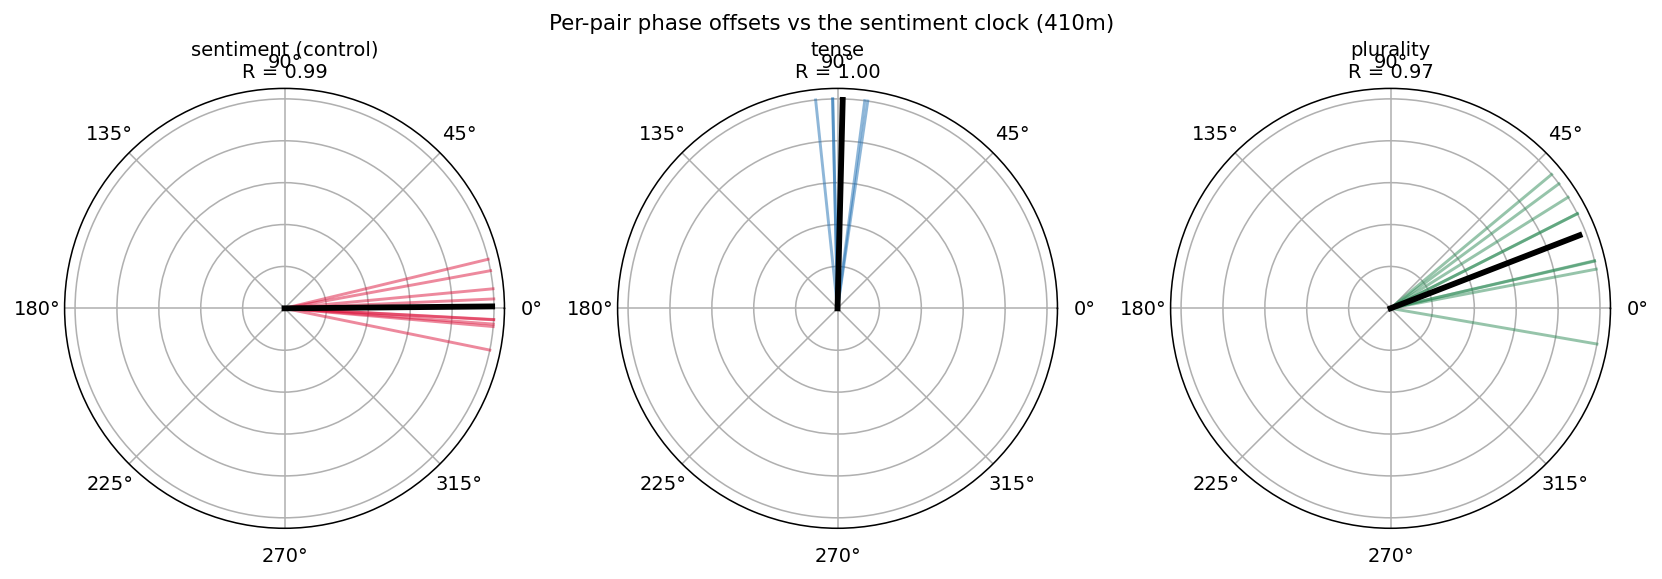

In [4]:
name = "pythia-410m"
model = HookedTransformer.from_pretrained_no_processing(name, dtype=torch.float16)
nL = model.cfg.n_layers
x = np.linspace(0, 1, nL)

def all_layer_means(prompts):
    outs = []
    for p in prompts:
        _, c = model.run_with_cache(model.to_tokens(p))
        outs.append(torch.stack([c["resid_post", L][0].mean(dim=0).float()
                                 for L in range(nL)]))
    return torch.stack(outs)

def build_axes(setA, setB):
    A, B = all_layer_means(setA), all_layer_means(setB)
    return {L: (lambda a: a / a.norm())(A[:, L].mean(0) - B[:, L].mean(0))
            for L in range(nL)}

def per_pair_curves(axes, pairs):
    out = []
    for s_a, s_b in pairs:
        tpk, tnk = model.to_tokens(s_a), model.to_tokens(s_b)
        f, win = flip_and_window(tpk, tnk)
        if f is None: continue
        _, cp = model.run_with_cache(tpk); _, cn = model.run_with_cache(tnk)
        curve = []
        for L in range(nL):
            dvec = (cp["resid_post", L][0] - cn["resid_post", L][0]).float()
            ax = axes[L]
            on  = (dvec @ ax).abs()[win[0]:win[1]].mean().item()
            off = (dvec - (dvec @ ax)[:, None] * ax[None, :]).norm(dim=-1)[win[0]:win[1]].mean().item()
            curve.append(on / off)
        out.append(curve); del cp, cn
    return np.array(out)

def detrend(row):
    return row - np.polyval(np.polyfit(x, row, 2), x)

sent_axes  = build_axes(pos_matched, neg_matched)
tense_axes = build_axes(past_ax, pres_ax)
plur_axes  = build_axes(plur_ax, sing_ax)

P_s = per_pair_curves(sent_axes,  sent_pairs)
P_t = per_pair_curves(tense_axes, tense_pairs)
P_p = per_pair_curves(plur_axes,  plural_pairs)

# reference wave: sentiment's MEAN curve (the network's clock as best measured)
w_ref = detrend(P_s.mean(0))
ph_ref = np.unwrap(np.angle(hilbert(w_ref)))
amp_ref = np.abs(hilbert(w_ref))
ref_loud = amp_ref > 0.35 * amp_ref.max()

def per_pair_offsets(P, label):
    """Phase offset of each pair's individual wave vs the sentiment reference."""
    offs = []
    for row in P:
        w = detrend(row)
        a = hilbert(w)
        ph, amp = np.unwrap(np.angle(a)), np.abs(a)
        loud = ref_loud & (amp > 0.35 * amp.max())
        if loud.sum() < 4:          # too few joint-loud layers -> this pair abstains
            continue
        z = np.mean(np.exp(1j * (ph[loud] - ph_ref[loud])))
        offs.append(np.angle(z))
    offs = np.array(offs)
    Z = np.mean(np.exp(1j * offs))
    R, mu = np.abs(Z), np.angle(Z)
    # Rayleigh test: p-value for "offsets are uniform on the circle"
    n = len(offs)
    p_ray = np.exp(-n * R**2) * (1 + (2*n*R**2 - n**2 * R**4) / (4*n)) if n > 0 else 1.0
    print(f"{label}: n = {n} pairs testify | "
          f"mean Δφ = {mu:+.2f} rad ({abs(mu)/np.pi:.2f}·π) | "
          f"R = {R:.2f} | Rayleigh p ≈ {p_ray:.3f}")
    print(f"   per-pair offsets (rad): {np.round(offs, 2)}")
    return offs, R, mu

print("--- per-pair phase offsets vs the sentiment clock ---")
offs_t, R_t, mu_t = per_pair_offsets(P_t, "TENSE    ")
offs_p, R_p, mu_p = per_pair_offsets(P_p, "PLURALITY")

# positive control: sentiment pairs vs their own mean — should cluster tightly
offs_s, R_s, mu_s = per_pair_offsets(P_s, "SENTIMENT (self-control)")

fig, ax_ = plt.subplots(1, 3, figsize=(12, 4), dpi=140,
                        subplot_kw={'projection': 'polar'})
for a, (offs, R, mu, label, col) in zip(ax_, [
        (offs_s, R_s, mu_s, "sentiment (control)", '#dc143c'),
        (offs_t, R_t, mu_t, "tense", '#1f6fb2'),
        (offs_p, R_p, mu_p, "plurality", '#2e8b57')]):
    for o in offs:
        a.plot([o, o], [0, 1], '-', color=col, alpha=0.5, lw=1.5)
    a.plot([mu, mu], [0, R], '-', color='black', lw=3)
    a.set_yticklabels([]); a.set_title(f"{label}\nR = {R:.2f}", fontsize=10)
plt.suptitle("Per-pair phase offsets vs the sentiment clock (410m)", fontsize=11)
plt.tight_layout()
plt.savefig("per_pair_phase_410m.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()

del model; gc.collect(); torch.cuda.empty_cache()


Verdict: the control passes and the slot structure is real — but not the one predicted. Sentiment pairs against their own mean cluster at R = 0.99 (instrument validated). Tense: five testifying pairs report offsets 1.44–1.68 rad, mean +1.55 rad = 0.49π — quadrature to two decimals, R = 1.00, Rayleigh p < 0.001. This resolves ch5’s r = 0.008 exactly: two same-period waves at 90° correlate at zero — “uncorrelated” was orthogonality’s shadow all along. The scheduling claim returns stronger than ch5 stated it. P3 killed cleanly: plurality clusters at +0.37 rad ≈ 21° (R = 0.97, n = 9) — nowhere near tense’s 89°. Grammatical features do not share a slot; three features hold three distinct angles on one clock. Phase appears to encode feature identity, not class. Check 2’s mystery also resolves: a genuinely different period would drift against the reference and collapse per-pair R; 0.97 says plurality shares the ~2.7 clock and the 3.98 was the suspected artifact — two instruments now corroborating.
Caveats, stated plainly: 3 of 8 tense pairs abstained (< 4 joint-loud layers), so tense’s n = 5; the Rayleigh p values printed as −0.000 are a small-n correction artifact in the formula — read as p < 0.001; all offsets are relative to sentiment’s mean curve as the reference clock; plurality’s 21° vs the control’s 0° needs a two-sample circular test (e.g. Watson–Williams) before “distinct slot” is claimed over “sentiment’s slot, measured noisily”; one model (410m); the plurality axis may carry verb-agreement flavour from the ch2 sets; mechanism untested.